C’est une excellente approche de structurer ton projet en plusieurs étapes claires. Voici un plan détaillé pour ton projet utilisant les fichiers EPL_processed_results.csv et EPL_Standings.csv avec un réseau de neurones :



5. Évaluation du Modèle
	•	Performance sur l’Ensemble de Test : Évaluer le modèle sur l’ensemble de test pour voir comment il généralise.
	•	Analyse des Erreurs : Examiner où et comment le modèle fait des erreurs pour comprendre ses limites.

6. Amélioration et Itération
	•	Ajustement du Modèle : Modifier l’architecture, ré-entraîner, et tester à nouveau basé sur les résultats d’évaluation.
	•	Enrichissement des Données : Ajouter plus de données ou créer de nouvelles features pour améliorer la performance du modèle.

7. Déploiement (Optionnel)
	•	Déploiement du Modèle : Mettre le modèle en production pour qu’il puisse être utilisé pour faire des prédictions en temps réel ou selon le besoin.

Chaque étape devrait être documentée et testée pour assurer que le projet progresse comme prévu. Si tu as besoin d’aide sur des parties spécifiques de ce plan ou des exemples de code pour certaines étapes, n’hésite pas à demander !

# 1. Analyse des Données
	•	Exploration des Données : Examiner les fichiers pour comprendre les variables disponibles, leur type, et les valeurs manquantes.
	•	Statistiques Descriptives : Calculer des statistiques résumées (moyennes, médianes, écarts-types, etc.) pour avoir une idée de la distribution des données.

Processed Results Data Preview:
   Unnamed: 0   Season        Date     HomeTeam    AwayTeam FTR  HomeGoals  \
0           0  2011-12  2011-11-05      Arsenal   West Brom   H          3   
1           1  2011-12  2011-11-05  Aston Villa     Norwich   H          3   
2           2  2011-12  2011-11-05    Blackburn     Chelsea   A          0   
3           3  2011-12  2011-11-05    Liverpool     Swansea   D          0   
4           4  2011-12  2011-11-05   Man United  Sunderland   H          1   

   AwayGoals  StandingDiff  HomeWins  ...  AvgHomeShots  AvgAwayShots  \
0          0            -7      80.0  ...          16.0           9.6   
1          2            -9      40.0  ...          10.6          11.6   
2          1            13      20.0  ...          12.8          18.2   
3          0           -12      40.0  ...          16.2          10.2   
4          0            -9      80.0  ...          18.6          13.0   

   AvgHomeShotsOnTarget  AvgAwayShotsOnTarget  AvgHomeCorner

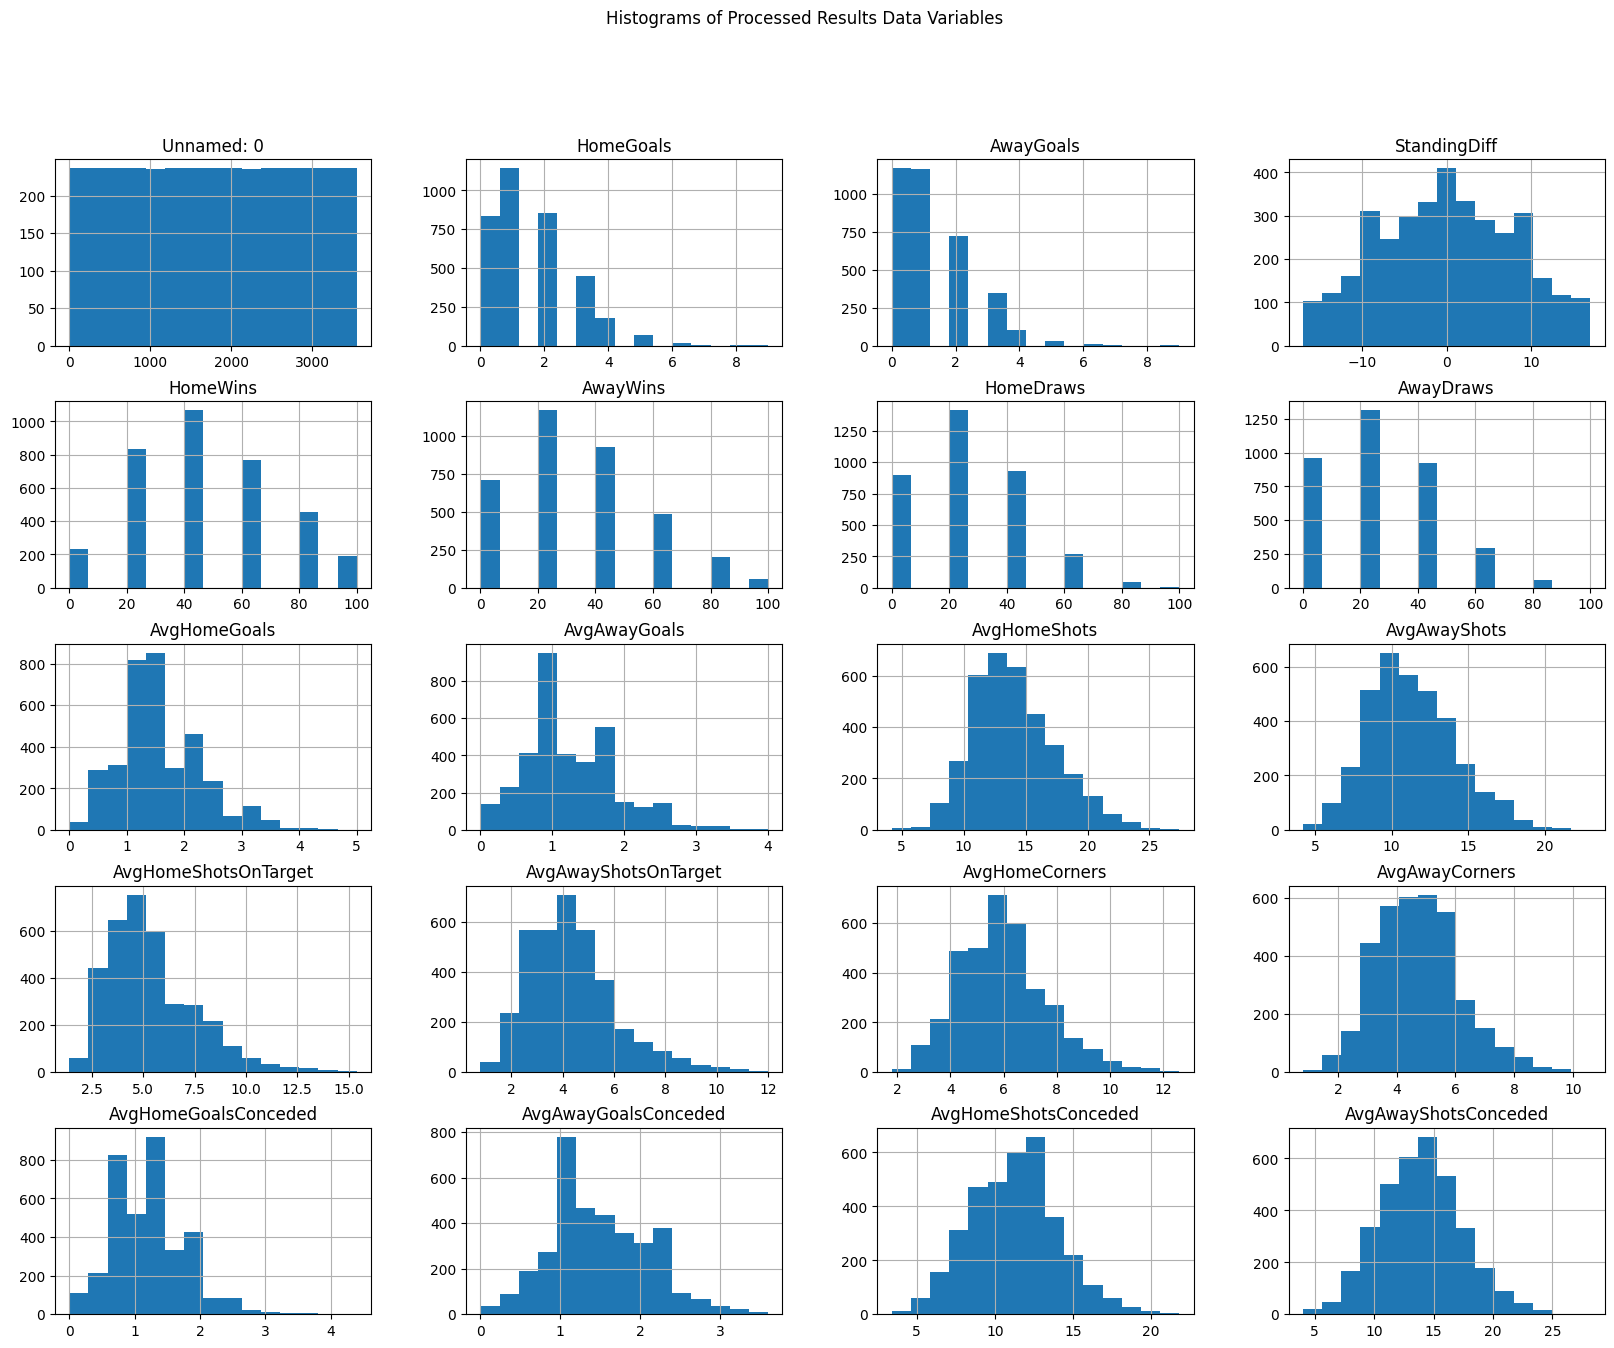

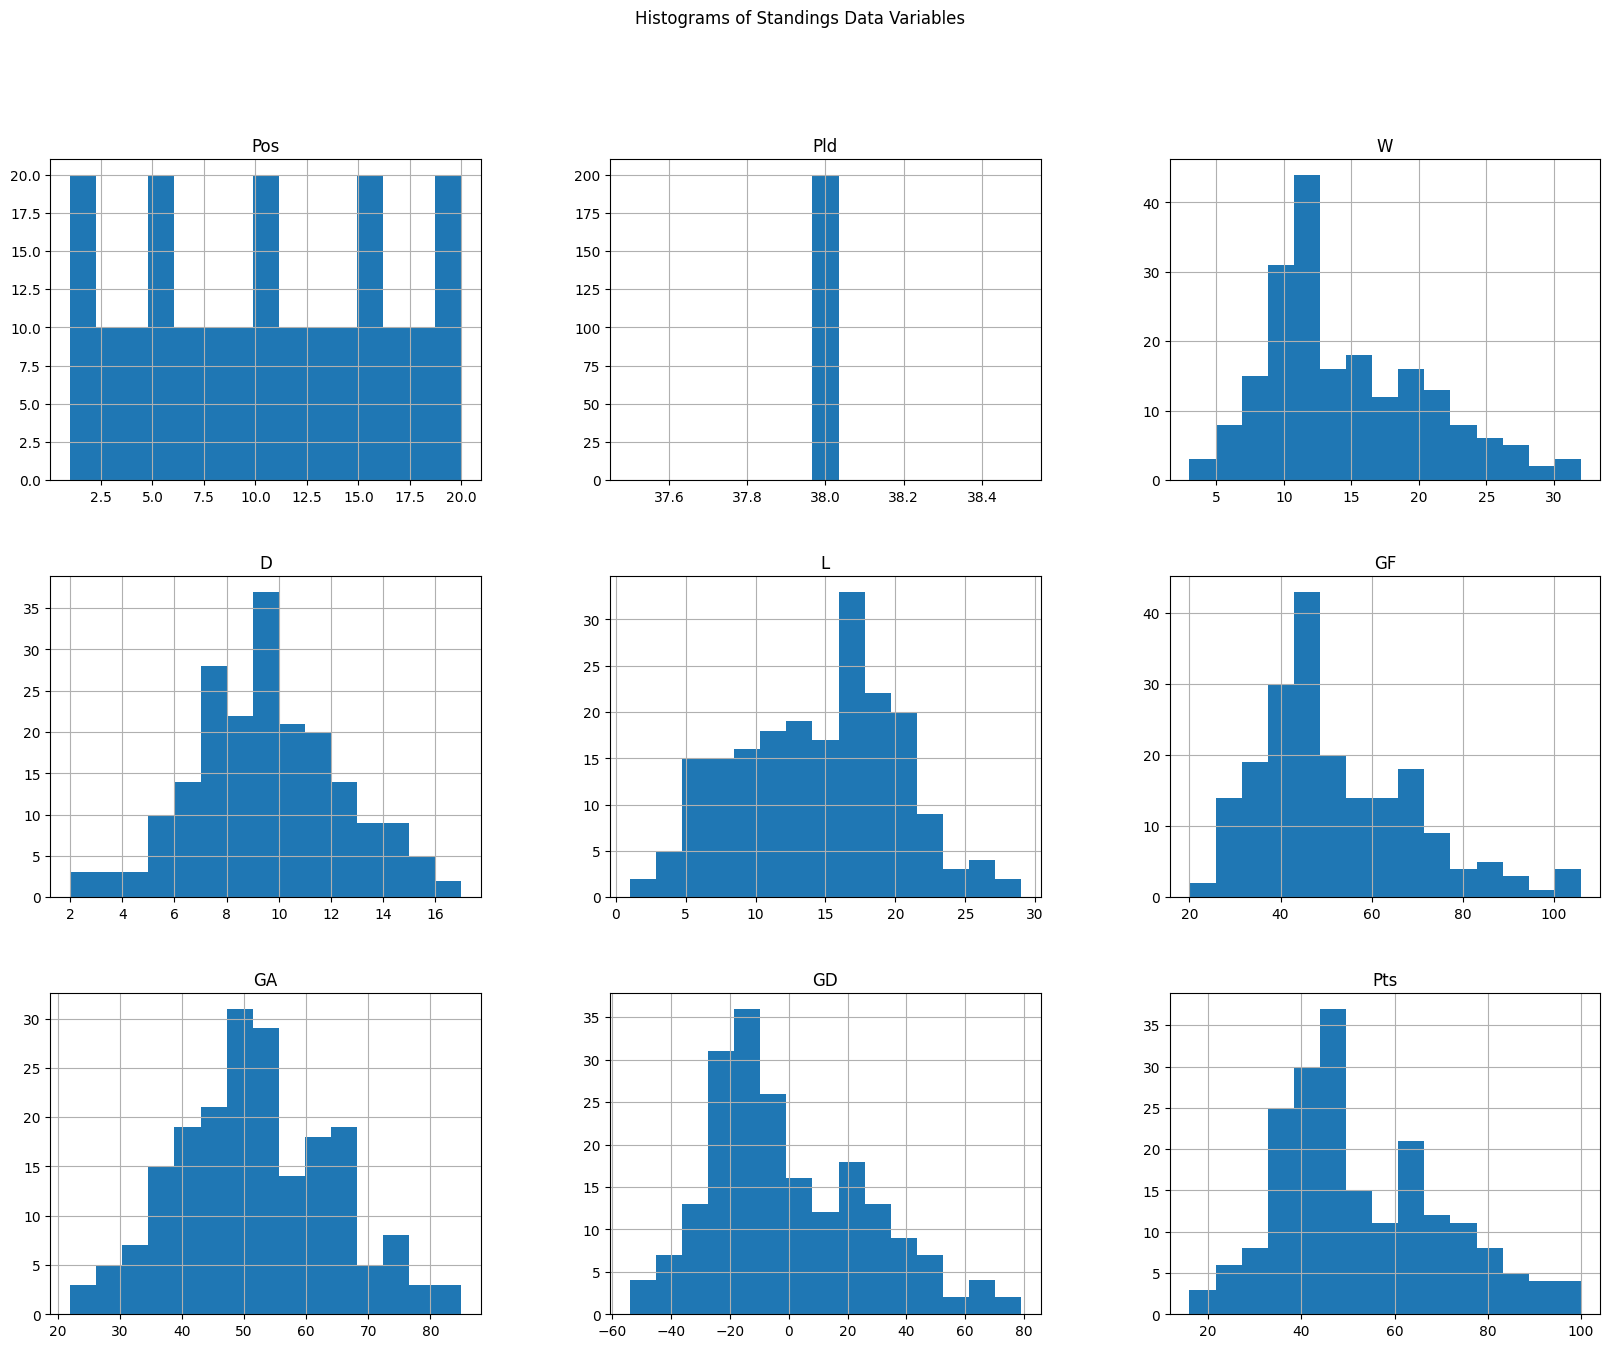

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger les données
data_results = pd.read_csv('EPL_processed_results.csv')
data_standings = pd.read_csv('EPL_Standings.csv')

# Afficher les premières lignes des données pour une exploration initiale
print("Processed Results Data Preview:")
print(data_results.head())
print("\nStandings Data Preview:")
print(data_standings.head())

# Afficher les informations sur les données pour comprendre les types de données et les valeurs manquantes
print("\nProcessed Results Data Info:")
data_results.info()
print("\nStandings Data Info:")
data_standings.info()

# Statistiques Descriptives
print("\nProcessed Results Descriptive Statistics:")
print(data_results.describe())
print("\nStandings Descriptive Statistics:")
print(data_standings.describe())

# Histogrammes pour visualiser les distributions
data_results.hist(bins=15, figsize=(20, 15))
plt.suptitle('Histograms of Processed Results Data Variables')
plt.show()

data_standings.hist(bins=15, figsize=(20, 15))
plt.suptitle('Histograms of Standings Data Variables')
plt.show()

# 2. Prétraitement des Données

## 	 Nettoyage des Données : Gérer les valeurs manquantes, supprimer ou remplir les données manquantes.


In [12]:
# Supprimer la colonne non nommée dans les résultats traités
data_results.drop(columns=['Unnamed: 0'], inplace=True)

# Vérifier les valeurs manquantes et les remplir si nécessaire
data_results.fillna(method='ffill', inplace=True)  # Remplissage par propagation avant
data_standings.fillna(method='ffill', inplace=True)

/var/folders/mn/8kzb8nld6yz1x00ppzbkn5x40000gn/T/ipykernel_16987/2451137432.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_results.fillna(method='ffill', inplace=True)  # Remplissage par propagation avant
/var/folders/mn/8kzb8nld6yz1x00ppzbkn5x40000gn/T/ipykernel_16987/2451137432.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_standings.fillna(method='ffill', inplace=True)


Dans le contexte de prédire le classement ou les points des équipes de la Premier League, utiliser directement l’année ou la saison comme feature peut être peu informatif et risque de créer un modèle qui n’est pas généralisable. Cependant, il existe des méthodes pour transformer la variable Season de façon à capturer des informations temporelles utiles sans introduire un biais direct lié à l’année spécifique.

In [13]:
# Supposons que `data_standings` est trié par équipe et par saison
data_standings.sort_values(by=['Team', 'Season'], inplace=True)

# Calculer la différence de points par rapport à la saison précédente
data_standings['Points_Diff'] = data_standings.groupby('Team')['Pts'].diff()

# Si la première saison d'une équipe n'a pas de saison précédente, remplir la différence par 0 ou une autre valeur neutre
data_standings['Points_Diff'].fillna(0, inplace=True)
# Calculer le taux de croissance des points
data_standings['Points_Growth'] = data_standings.groupby('Team')['Pts'].pct_change().fillna(0)
# Calculer la moyenne mobile des points sur les 3 dernières saisons
data_standings['Points_MA'] = data_standings.groupby('Team')['Pts'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

/var/folders/mn/8kzb8nld6yz1x00ppzbkn5x40000gn/T/ipykernel_16987/800629880.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_standings['Points_Diff'].fillna(0, inplace=True)


In [14]:
# Convertir la colonne 'Date' en type datetime
data_results['Date'] = pd.to_datetime(data_results['Date'])

# Extraire le mois, l'année et le jour de la semaine
data_results['Month'] = data_results['Date'].dt.month
data_results['Year'] = data_results['Date'].dt.year
data_results['DayOfWeek'] = data_results['Date'].dt.dayofweek

# Supprimer la colonne 'Date'
data_results.drop('Date', axis=1, inplace=True)


## Intégration des Données : Fusionner les données de EPL_processed_results.csv et EPL_Standings.csv si nécessaire pour créer un dataset complet.


In [15]:

# Obtenir les ensembles uniques des équipes
teams_results = set(data_results['HomeTeam'].unique()).union(set(data_results['AwayTeam'].unique()))
teams_standings = set(data_standings['Team'].unique())

# Afficher les listes pour vérification visuelle
print("Teams in Results Data:", teams_results)
print("Teams in Standings Data:", teams_standings)

# Trouver les différences
missing_in_results = teams_standings - teams_results
missing_in_standings = teams_results - teams_standings

# Afficher les différences
print("Missing in Results Data:", missing_in_results)
print("Missing in Standings Data:", missing_in_standings)

# Suppression des lignes correspondant aux équipes manquantes
data_results = data_results[~data_results['HomeTeam'].isin(['Blackpool', 'Birmingham'])]
data_results = data_results[~data_results['AwayTeam'].isin(['Blackpool', 'Birmingham'])]
data_standings = data_standings[~data_standings['Team'].isin(['Brentford'])]

# Fusion des données ajustées
combined_data = pd.merge(data_results, data_standings, how='left', left_on=['Season', 'HomeTeam'], right_on=['Season', 'Team'])

Teams in Results Data: {'Huddersfield', 'Chelsea', 'Fulham', 'West Brom', 'Wigan', 'Burnley', 'Man United', 'West Ham', 'Leicester', 'Bournemouth', 'Blackburn', 'Sunderland', 'Liverpool', 'Stoke', 'Crystal Palace', 'Arsenal', 'Reading', 'Everton', 'Brighton', 'Cardiff', 'Man City', 'Middlesbrough', 'Sheffield United', 'Leeds', 'Tottenham', 'Norwich', 'Swansea', 'Newcastle', 'Bolton', 'QPR', 'Wolves', 'Hull', 'Aston Villa', 'Watford', 'Southampton'}
Teams in Standings Data: {'Huddersfield', 'Chelsea', 'Burnley', 'Fulham', 'West Brom', 'Wigan', 'Man United', 'West Ham', 'Leicester', 'Bournemouth', 'Blackburn', 'Sunderland', 'Liverpool', 'Crystal Palace', 'Stoke', 'Arsenal', 'Reading', 'Everton', 'Brighton', 'Cardiff', 'Man City', 'Middlesbrough', 'Sheffield United', 'Leeds', 'Tottenham', 'Norwich', 'Swansea', 'Newcastle', 'Bolton', 'QPR', 'Wolves', 'Hull', 'Aston Villa', 'Watford', 'Southampton'}
Missing in Results Data: set()
Missing in Standings Data: set()


## Création de Nouvelles Variables : Développer des variables calculées (par exemple, le taux de victoire, ratio buts pour contre buts contre) qui pourraient être utiles pour la prédiction.

In [16]:
# Calcul du ratio de victoires à domicile
combined_data['HomeWinRate'] = combined_data['HomeWins'] / combined_data['Pld']

# Ratio de buts pour contre buts contre à domicile
combined_data['HomeGoalRatio'] = combined_data['GF'] / combined_data['GA']

## Encodage : Transformer les variables catégorielles en variables numériques utilisables par le modèle de réseau de neurones.

In [17]:
# Encodage One-Hot pour les équipes et le résultat du match
combined_data = pd.get_dummies(combined_data, columns=['HomeTeam', 'AwayTeam'])

# Normalisation : Standardiser ou normaliser les caractéristiques pour que le modèle de réseau de neurones converge plus efficacement.

In [22]:
from sklearn.preprocessing import StandardScaler

# Créer un objet scaler
scaler = StandardScaler()

# Sélection des colonnes à normaliser
features = ['HomeGoals', 'AwayGoals']  # ajoutez d'autres selon les besoins
combined_data[features] = scaler.fit_transform(combined_data[features])

3. Division des Données
	•	Ensemble d’Entraînement et de Test : Séparer les données en un ensemble d’entraînement et un ensemble de test. Typiquement, 80% pour l’entraînement et 20% pour les tests.
	•	Validation Croisée : Préparer des ensembles pour la validation croisée pour l’ajustement des paramètres du modèle.

In [23]:


# Sélectionner les features et la cible
X = combined_data.drop(columns=['Pts', 'Team', 'Season', 'FTR', 'Qualification or relegation'])  # Exclure la cible et autres colonnes non prédictives
y = combined_data['FTR']  # Utiliser le resultat de match comme cible

from sklearn.model_selection import train_test_split

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 20% des données pour le test


In [24]:
import torch
from torch_geometric.data import Data
from sklearn.preprocessing import LabelEncoder

# Encoder les cibles
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_train)

# Conversion des DataFrame en Tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float)
y_train_tensor = torch.tensor(y_encoded, dtype=torch.long)

# Créer un simple graphe complet (chaque nœud est connecté à chaque autre nœud)
edge_index = torch.combinations(torch.arange(X_train_tensor.size(0)), r=2).t().contiguous()

# Créer les données pour PyTorch Geometric
data = Data(x=X_train_tensor, edge_index=edge_index, y=y_train_tensor)

TypeError: can't convert np.ndarray of type numpy.object_. The only supported types are: float64, float32, float16, complex64, complex128, int64, int32, int16, int8, uint64, uint32, uint16, uint8, and bool.

In [28]:
non_numeric_columns = X.select_dtypes(exclude=['number']).columns.tolist()
print("Colonnes non numériques :", non_numeric_columns)

Colonnes non numériques : ['HomeTeam_Arsenal', 'HomeTeam_Aston Villa', 'HomeTeam_Blackburn', 'HomeTeam_Bolton', 'HomeTeam_Bournemouth', 'HomeTeam_Brighton', 'HomeTeam_Burnley', 'HomeTeam_Cardiff', 'HomeTeam_Chelsea', 'HomeTeam_Crystal Palace', 'HomeTeam_Everton', 'HomeTeam_Fulham', 'HomeTeam_Huddersfield', 'HomeTeam_Hull', 'HomeTeam_Leeds', 'HomeTeam_Leicester', 'HomeTeam_Liverpool', 'HomeTeam_Man City', 'HomeTeam_Man United', 'HomeTeam_Middlesbrough', 'HomeTeam_Newcastle', 'HomeTeam_Norwich', 'HomeTeam_QPR', 'HomeTeam_Reading', 'HomeTeam_Sheffield United', 'HomeTeam_Southampton', 'HomeTeam_Stoke', 'HomeTeam_Sunderland', 'HomeTeam_Swansea', 'HomeTeam_Tottenham', 'HomeTeam_Watford', 'HomeTeam_West Brom', 'HomeTeam_West Ham', 'HomeTeam_Wigan', 'HomeTeam_Wolves', 'AwayTeam_Arsenal', 'AwayTeam_Aston Villa', 'AwayTeam_Blackburn', 'AwayTeam_Bolton', 'AwayTeam_Bournemouth', 'AwayTeam_Brighton', 'AwayTeam_Burnley', 'AwayTeam_Cardiff', 'AwayTeam_Chelsea', 'AwayTeam_Crystal Palace', 'AwayTeam_Ev

In [29]:
non_numeric_types = {col: X[col].dtype for col in non_numeric_columns}
print(non_numeric_types)

{'HomeTeam_Arsenal': dtype('bool'), 'HomeTeam_Aston Villa': dtype('bool'), 'HomeTeam_Blackburn': dtype('bool'), 'HomeTeam_Bolton': dtype('bool'), 'HomeTeam_Bournemouth': dtype('bool'), 'HomeTeam_Brighton': dtype('bool'), 'HomeTeam_Burnley': dtype('bool'), 'HomeTeam_Cardiff': dtype('bool'), 'HomeTeam_Chelsea': dtype('bool'), 'HomeTeam_Crystal Palace': dtype('bool'), 'HomeTeam_Everton': dtype('bool'), 'HomeTeam_Fulham': dtype('bool'), 'HomeTeam_Huddersfield': dtype('bool'), 'HomeTeam_Hull': dtype('bool'), 'HomeTeam_Leeds': dtype('bool'), 'HomeTeam_Leicester': dtype('bool'), 'HomeTeam_Liverpool': dtype('bool'), 'HomeTeam_Man City': dtype('bool'), 'HomeTeam_Man United': dtype('bool'), 'HomeTeam_Middlesbrough': dtype('bool'), 'HomeTeam_Newcastle': dtype('bool'), 'HomeTeam_Norwich': dtype('bool'), 'HomeTeam_QPR': dtype('bool'), 'HomeTeam_Reading': dtype('bool'), 'HomeTeam_Sheffield United': dtype('bool'), 'HomeTeam_Southampton': dtype('bool'), 'HomeTeam_Stoke': dtype('bool'), 'HomeTeam_Sunde


# 4. Modélisation
	•	Choix de l’Architecture du Réseau de Neurones : Déterminer le nombre de couches cachées, le nombre de neurones par couche, les fonctions d’activation, etc.
	•	Compilation du Modèle : Choisir l’optimiseur, la fonction de perte, et les métriques de performance.
	•	Entraînement du Modèle : Entraîner le modèle sur les données d’entraînement en utilisant des callbacks comme EarlyStopping pour éviter le surajustement.
	•	Tuning des Hyperparamètres : Ajuster les hyperparamètres du modèle en utilisant par exemple GridSearchCV ou une approche manuelle.


## 4.1 Choix de l'architecture du réseaux de neurones 

In [95]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import numpy as np

# Création de l'encodeur
label_encoder = LabelEncoder()

# Ajustement de l'encodeur sur les données et transformation
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.fit_transform(y_test)

# Affichage des catégories encodées
print("Encoded labels:", y_train_encoded)

# One-Hot Encoding
y_train_one_hot = to_categorical(y_train_encoded)
print("One-Hot Encoded labels:\n", y_train_one_hot)

Encoded labels: [2 1 0 ... 0 2 0]
One-Hot Encoded labels:
 [[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 ...
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]


In [84]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasClassifier

def create_model(optimizer='adam', neurons=32):
    model = Sequential([
        Dense(neurons, input_shape=(X_train.shape[1],), activation='relu'),
        Dense(neurons, activation='relu'),
        Dense(3, activation='softmax')  # 3 pour 'H', 'D', 'A'
    ])
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

    model = KerasClassifier(model=create_model, verbose=0)

# 4.2 

In [85]:
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV

# Définition du modèle Keras à utiliser dans GridSearch
def create_model(neurons=32):
    model = Sequential([
        Dense(neurons, input_dim=X_train.shape[1], activation='relu'),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
    return model

# Wrap du modèle Keras pour utiliser avec scikit-learn
model = KerasRegressor(model=create_model, verbose=0)

# Définition des hyperparamètres pour tester
param_grid = {
    'model__neurons': [32, 64],
    'epochs': [50, 100],
    'batch_size': [16, 32]
}

# Création de GridSearchCV
grid = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=-1, cv=3, scoring='accuracy')
grid_result = grid.fit(X_train, y_train_encoded)  # Assure-toi que y_train_encoded sont des labels entiers, pas one-hot encoded

# Affichage des meilleurs paramètres et du meilleur score
print("Meilleurs: %f utilisant %s" % (grid_result.best_score_, grid_result.best_params_))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object 

Meilleurs: nan utilisant {'batch_size': 16, 'epochs': 50, 'model__neurons': 32}


In [87]:
# Meilleurs score et paramètres après GridSearch
best_score = grid_result.best_score_
best_params = grid_result.best_params_

print("Meilleur score: {:.4f}".format(best_score))
print("Meilleurs paramètres: {}".format(best_params))

Meilleur score: nan
Meilleurs paramètres: {'batch_size': 16, 'epochs': 50, 'model__neurons': 32}


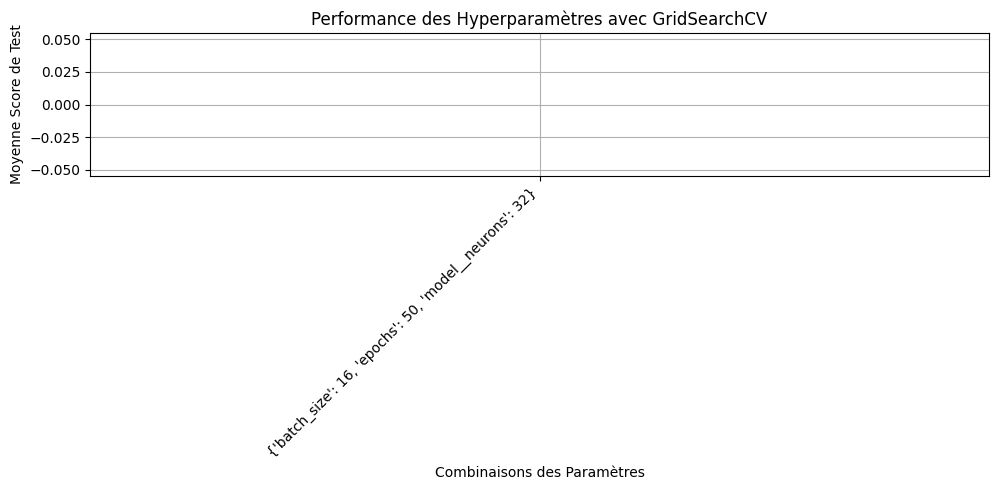

In [86]:
import matplotlib.pyplot as plt

# Supposons que tu as déjà exécuté GridSearchCV et obtenu les résultats dans grid_result
results = grid_result.cv_results_

# Préparation des données pour le graphique
mean_test_scores = results['mean_test_score']
std_test_scores = results['std_test_score']
params = [str(x) for x in results['params']]

# Création du graphique des performances de GridSearchCV
plt.figure(figsize=(10, 5))
plt.errorbar(params, mean_test_scores, yerr=std_test_scores, fmt='o', color='b', ecolor='lightgray', elinewidth=3, capsize=0)
plt.title('Performance des Hyperparamètres avec GridSearchCV')
plt.xlabel('Combinaisons des Paramètres')
plt.ylabel('Moyenne Score de Test')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [96]:
# Si tes prédictions sont probabilités, tu obtiens la classe prédite en prenant l'indice de la probabilité maximale
predicted_classes = model.predict(X_test)
predicted_classes = np.argmax(predicted_classes, axis=1)

# Si tes labels sont one-hot encoded, tu dois aussi les convertir en labels entiers
true_classes = np.argmax(y_test_encoded, axis=1)

AxisError: axis 1 is out of bounds for array of dimension 1

In [94]:
model.fit(X_train, y_train_encoded, epochs=100, batch_size=32)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


KerasRegressor(
	model=<function create_model at 0x33439eac0>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=0
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
)

In [92]:
predictions = model.predict(X_test)